In [1]:
# === Cell 1: Setup, Imports, and Data Loading ===

# --- Core Data Handling & System Libraries ---
import pandas as pd
import sqlite3
import os

# --- Visualization Libraries ---
import seaborn as sns
import matplotlib.pyplot as plt

# --- Scikit-learn for Feature Extraction and Similarity ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --- Notebook Setup ---
# Configure pandas display options for wider tables
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)

print("--- Starting Cosine Similarity Analysis Notebook ---")

# --- Define Database Path ---
# This assumes the database is in the same folder as this notebook.
db_name = "mooc_analyzer.db"
table_name = "reviews"

# --- Load Data from SQLite Database ---
print(f"\n--- Loading Final Analyzed Data from '{db_name}' ---")

# Check if the database file exists before trying to connect
if os.path.exists(db_name):
    try:
        # Establish a connection to the database
        conn = sqlite3.connect(db_name)
        
        # Use a SELECT query to load the entire 'reviews' table into a pandas DataFrame
        query = f"SELECT * FROM {table_name}"
        df_final = pd.read_sql_query(query, conn)
        
        # Close the database connection
        conn.close()
        
        # Ensure 'Lemmatized_Text' is treated as a string and fill any potential null values
        df_final['Lemmatized_Text'] = df_final['Lemmatized_Text'].fillna('').astype(str)
        
        print(f"Successfully loaded {len(df_final)} rows from the '{table_name}' table.")
        display(df_final.head())
        
    except Exception as e:
        print(f"[ERROR] Failed to load data from the database: {e}")
        df_final = pd.DataFrame() # Create an empty DataFrame to prevent errors
else:
    print(f"[ERROR] Database file not found: {db_name}. Please ensure the modeling notebook has been run.")
    df_final = pd.DataFrame()

--- Starting Cosine Similarity Analysis Notebook ---

--- Loading Final Analyzed Data from 'mooc_analyzer.db' ---
Successfully loaded 7910 rows from the 'reviews' table.


,Platform,Question_Log_URL,Date,Sentence_Text,Lemmatized_Text,Aspect_Label,sentiment_label,predicted_aspect,predicted_sentiment
0,Coursera,https://www.quora.com/Is-a-Coursera-certificat...,"October 25, 2024 at 10:33:45 PM","Yes, a Coursera certificate can be quite useful.",yes coursera certificate quite useful,Assessment,Positive,Assessment,Positive
1,Coursera,https://www.quora.com/Is-a-Coursera-certificat...,"October 25, 2024 at 10:33:45 PM",While it may not hold the same weight as a deg...,may hold weight degree demonstrate commitment ...,Content,Positive,Content,Positive
2,Coursera,https://www.quora.com/Is-a-Coursera-certificat...,"October 25, 2024 at 10:33:45 PM","Many employers recognize Coursera courses, esp...",many employer recognize coursera course especi...,Content,Positive,Content,Positive
3,Coursera,https://www.quora.com/Is-a-Coursera-certificat...,"October 25, 2024 at 10:33:45 PM","Additionally, completing these courses can hel...",additionally complete course help gain practic...,Content,Positive,Content,Positive
4,Coursera,https://www.quora.com/Is-a-Coursera-certificat...,"October 25, 2024 at 10:33:45 PM",If you're looking for more certification optio...,youre look certification option could compleme...,Content,Positive,Content,Positive


In [2]:
# === Cell 2: Calculate and Store Platform Similarity ===

import pandas as pd
import sqlite3
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("--- Starting Platform Cosine Similarity Calculation ---")

# Ensure the final DataFrame from Cell 1 is available.
if 'df_final' in locals() and not df_final.empty:
    
    # --- 1. Define Core Components ---
    # List of the aspects you want to analyze.
    aspect_labels = ['Content', 'Structure', 'Assessment', 'Interaction', 'Instructor']
    # List of the platforms to compare.
    platform_names = ['Coursera', 'edX', 'Udemy']
    
    # --- 2. Database Setup for Storing Scores ---
    db_name = "mooc_analyzer.db"
    table_name = "platform_aspect_similarity"
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    # Create the table if it doesn't already exist.
    # 'INSERT OR REPLACE' will be used to ensure the data is always up-to-date.
    cursor.execute(f'''
        CREATE TABLE IF NOT EXISTS {table_name} (
            aspect TEXT NOT NULL,
            platform_a TEXT NOT NULL,
            platform_b TEXT NOT NULL,
            similarity_score REAL NOT NULL,
            UNIQUE(aspect, platform_a, platform_b)
        )
    ''')
    conn.commit()
    print(f"\nDatabase '{db_name}' connected and '{table_name}' table ensured.")
    
    # This dictionary will hold the similarity DataFrames for visualization later.
    all_aspect_similarity_data = {}

    # --- 3. Loop Through Each Aspect to Calculate Similarity ---
    for aspect in aspect_labels:
        print(f"\n--- Processing Aspect: {aspect} ---")
        
        # Filter the DataFrame to get only the rows for the current aspect.
        aspect_df = df_final[df_final['Aspect_Label'] == aspect]
        
        # --- Aggregate Text for Each Platform ---
        # This creates a single large block of text for each platform for the current aspect.
        platform_texts = []
        current_platforms_in_aspect = []
        for platform in platform_names:
            platform_aspect_data = aspect_df[aspect_df['Platform'] == platform]
            # Only proceed if there is text data for this platform/aspect combo.
            if not platform_aspect_data.empty and not platform_aspect_data['Lemmatized_Text'].isnull().all():
                aggregated_text = " ".join(platform_aspect_data['Lemmatized_Text'].dropna().tolist())
                if aggregated_text.strip():
                    platform_texts.append(aggregated_text)
                    current_platforms_in_aspect.append(platform)
        
        # We need at least two platforms with text to make a comparison.
        if len(platform_texts) < 2:
            print(f"  Skipping aspect '{aspect}', not enough platform data for comparison.")
            continue
            
        try:
            # --- Vectorize and Calculate Similarity ---
            vectorizer = TfidfVectorizer()
            tfidf_matrix = vectorizer.fit_transform(platform_texts)
            cosine_sim_matrix = cosine_similarity(tfidf_matrix)
            
            # Store the results in a DataFrame for easy viewing.
            similarity_df = pd.DataFrame(cosine_sim_matrix, index=current_platforms_in_aspect, columns=current_platforms_in_aspect)
            all_aspect_similarity_data[aspect] = similarity_df
            
            print(f"  Similarity Matrix for Aspect '{aspect}':")
            display(similarity_df.round(3))
            
            # --- Store Pairwise Scores in the Database ---
            # Loop through the upper triangle of the matrix to get unique pairs.
            for i in range(len(current_platforms_in_aspect)):
                for j in range(i + 1, len(current_platforms_in_aspect)):
                    p_a = current_platforms_in_aspect[i]
                    p_b = current_platforms_in_aspect[j]
                    score = similarity_df.iloc[i, j]
                    
                    # Ensure consistent order of platform names for the unique constraint in the DB.
                    platform1_sorted, platform2_sorted = sorted([p_a, p_b])
                    
                    # Use INSERT OR REPLACE to update the score if it already exists.
                    cursor.execute(f'''
                        INSERT OR REPLACE INTO {table_name} (aspect, platform_a, platform_b, similarity_score)
                        VALUES (?, ?, ?, ?)
                    ''', (aspect, platform1_sorted, platform2_sorted, score))

            conn.commit()
            print(f"  Similarity scores for '{aspect}' saved to database.")

        except ValueError as ve:
            print(f"  [SKIPPING] Could not process aspect '{aspect}' (likely empty vocabulary): {ve}")
        except Exception as e:
            print(f"  [ERROR] An unexpected error occurred for aspect '{aspect}': {e}")
            
    # Close the database connection once all aspects are processed.
    conn.close()
    print("\n--- Cosine Similarity Calculation Complete ---")
    
else:
    print("[ERROR] 'df_final' DataFrame not found or empty. Halting process.")

--- Starting Platform Cosine Similarity Calculation ---

Database 'mooc_analyzer.db' connected and 'platform_aspect_similarity' table ensured.

--- Processing Aspect: Content ---
  Similarity Matrix for Aspect 'Content':


,Coursera,edX,Udemy
Coursera,1.000,0.93,0.747
edX,0.930,1.00,0.770
Udemy,0.747,0.77,1.000


  Similarity scores for 'Content' saved to database.

--- Processing Aspect: Structure ---
  Similarity Matrix for Aspect 'Structure':


,Coursera,edX,Udemy
Coursera,1.000,0.919,0.480
edX,0.919,1.000,0.476
Udemy,0.480,0.476,1.000


  Similarity scores for 'Structure' saved to database.

--- Processing Aspect: Assessment ---
  Similarity Matrix for Aspect 'Assessment':


...

  Similarity scores for 'Assessment' saved to database.

--- Processing Aspect: Interaction ---
  Similarity Matrix for Aspect 'Interaction':


,Coursera,edX,Udemy
Coursera,1.000,0.829,0.416
edX,0.829,1.000,0.409
Udemy,0.416,0.409,1.000


  Similarity scores for 'Interaction' saved to database.

--- Processing Aspect: Instructor ---
  Similarity Matrix for Aspect 'Instructor':


,Coursera,edX,Udemy
Coursera,1.000,0.604,0.434
edX,0.604,1.000,0.392
Udemy,0.434,0.392,1.000


  Similarity scores for 'Instructor' saved to database.

--- Cosine Similarity Calculation Complete ---


--- Starting Visualization of Similarity Scores ---

--- Heatmap for Aspect: Content ---


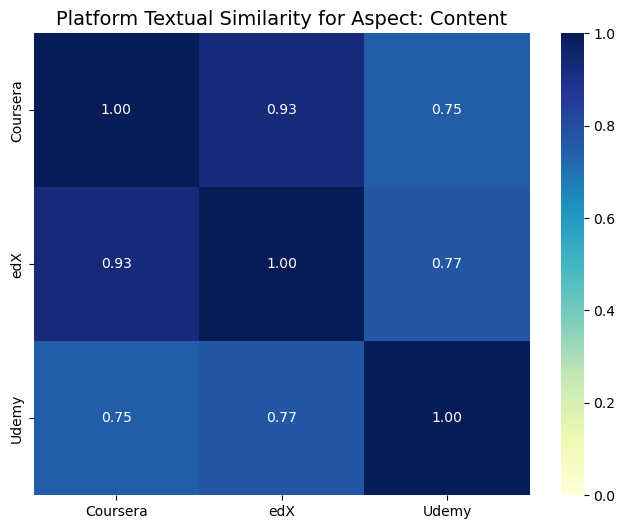


--- Heatmap for Aspect: Structure ---


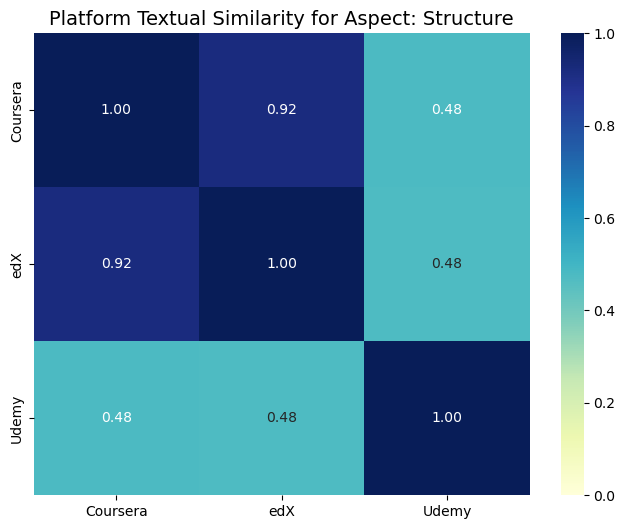


--- Heatmap for Aspect: Assessment ---


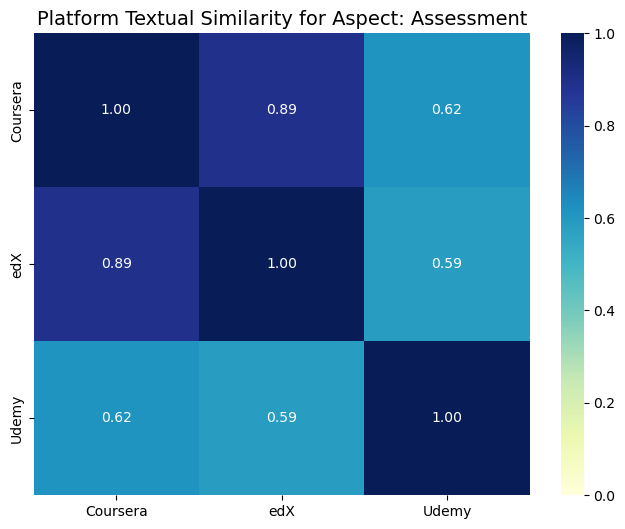


--- Heatmap for Aspect: Interaction ---


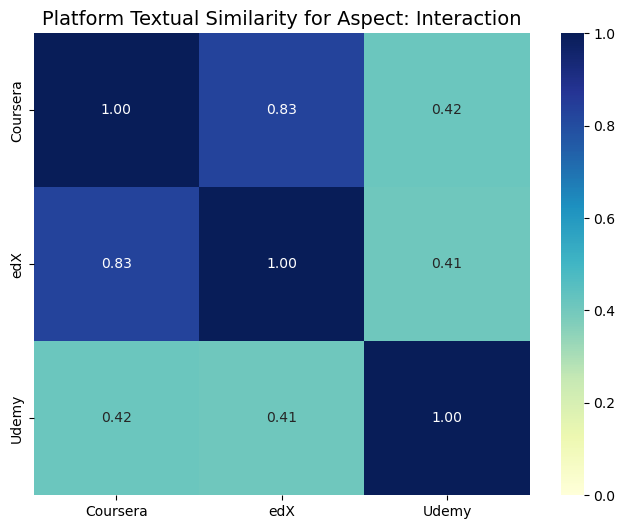


--- Heatmap for Aspect: Instructor ---


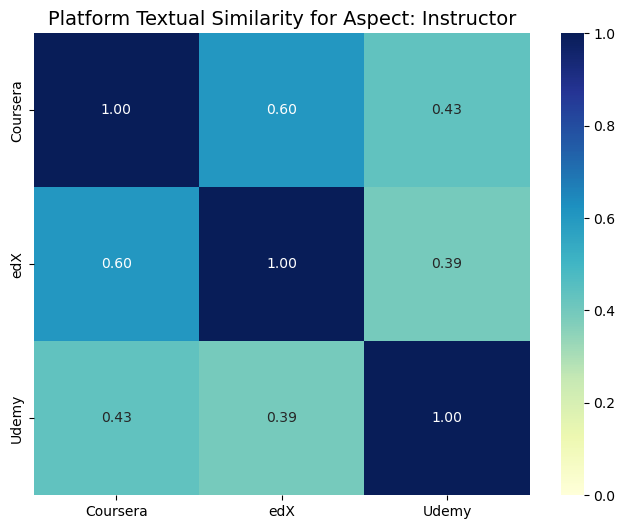


--- Visualization Complete ---


In [3]:
# === Cell 3: Visualize Similarity Scores with Heatmaps ===

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Starting Visualization of Similarity Scores ---")

# Ensure the dictionary containing the similarity data from Cell 2 is available.
if 'all_aspect_similarity_data' in locals() and all_aspect_similarity_data:
    
    # Loop through each aspect and its corresponding similarity DataFrame.
    for aspect, similarity_df in all_aspect_similarity_data.items():
        
        # Check if the DataFrame for the aspect is not empty.
        if not similarity_df.empty:
            
            print(f"\n--- Heatmap for Aspect: {aspect} ---")
            
            # --- Create the Heatmap ---
            # Set the figure size for better readability.
            plt.figure(figsize=(8, 6))
            
            # Use seaborn's heatmap function to create the visualization.
            # annot=True displays the similarity scores on the map.
            # cmap="YlGnBu" uses a pleasant blue-green color scheme.
            # fmt=".2f" formats the scores to two decimal places.
            sns.heatmap(
                similarity_df, 
                annot=True, 
                cmap="YlGnBu", 
                fmt=".2f",
                vmin=0,  # Set the minimum value of the color bar to 0.
                vmax=1   # Set the maximum value of the color bar to 1.
            )
            
            # Add a title to the chart.
            plt.title(f"Platform Textual Similarity for Aspect: {aspect}", fontsize=14)
            
            # Display the plot.
            plt.show()
            
        else:
            print(f"\n--- No data to visualize for Aspect: {aspect} ---")

else:
    print("[ERROR] 'all_aspect_similarity_data' not found or is empty. Please run Cell 2 first.")

print("\n--- Visualization Complete ---")